In [1]:
import pandas as pd

In [3]:
import numpy as np

In [61]:
df=pd.read_csv(r"C:\Users\suraj\Downloads\student_info.csv")

In [63]:
df

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19
...,...,...
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05


In [65]:
df.head()

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [67]:
df.tail()

,study_hours,student_marks
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05
199,8.35,83.50


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [71]:
df.shape

(200, 2)

In [73]:
df.describe()

,study_hours,student_marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


In [75]:
df.isnull().sum()

study_hours      5
student_marks    0
dtype: int64

In [77]:
df.duplicated().sum()

0

In [79]:
df.drop_duplicates()

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19
...,...,...
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05


In [81]:
print(df.columns)

Index(['study_hours', 'student_marks'], dtype='object')


In [85]:
df["study_hours"].value_counts()

study_hours
5.39    4
7.26    3
6.35    3
6.51    3
7.95    3
       ..
8.76    1
5.52    1
5.01    1
7.01    1
8.94    1
Name: count, Length: 144, dtype: int64

In [87]:
df.corr(numeric_only=True)

,study_hours,student_marks
study_hours,1.000000,0.979919
student_marks,0.979919,1.000000


In [89]:
from sklearn.model_selection import train_test_split
x=df["study_hours"]
y=df["student_marks"]
x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

In [93]:
print("X Train:")
print(x_train)

print("X Test:")
print(x_test)

print("Y Train:")
print(y_train)

print("Y Test:")
print(y_test)

X Train:
79     5.88
197    8.94
38     5.62
24     5.45
122     NaN
       ... 
106    5.34
14     8.19
92     5.44
179    7.26
102    8.26
Name: study_hours, Length: 160, dtype: float64
X Test:
95     6.09
15     6.55
30     8.13
158    7.53
128    6.38
115    5.79
69     8.25
170    5.19
174    5.39
45     6.18
66     7.86
182    8.66
165    5.38
78     5.09
186    8.87
177    5.79
56     5.75
152    8.08
82     6.66
68     5.07
124    8.69
16     6.36
148    8.30
93     7.90
65     5.45
60     5.49
84     6.88
67     8.26
125    8.75
132    6.83
9      6.75
18     8.41
55     8.69
75     6.04
150    5.39
104    7.23
135    8.33
137    5.14
164    7.87
76     5.11
Name: study_hours, dtype: float64
Y Train:
79     73.34
197    86.75
38     73.08
24     70.96
122    76.83
       ...  
106    72.10
14     83.08
92     72.08
179    78.17
102    82.99
Name: student_marks, Length: 160, dtype: float64
Y Test:
95     76.48
15     76.03
30     82.27
158    81.57
128    77.01
115    74.44
69 

# ML_Day3

In [69]:
# Step 1 — Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [71]:
# Step 2 — Load Dataset
df1=pd.read_csv(r"D:\Machine_Learning_Project\USA_House_price\USA_Housing.csv")

In [73]:
print(df1.head())

   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA...  
2  9127 Eli

In [75]:
print(df1.shape)

(5000, 7)


In [77]:
print(df1.info)

<bound method DataFrame.info of       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0         79545.458574             5.682861                   7.009188   
1         79248.642455             6.002900                   6.730821   
2         61287.067179             5.865890                   8.512727   
3         63345.240046             7.188236                   5.586729   
4         59982.197226             5.040555                   7.839388   
...                ...                  ...                        ...   
4995      60567.944140             7.830362                   6.137356   
4996      78491.275435             6.999135                   6.576763   
4997      63390.686886             7.250591                   4.805081   
4998      68001.331235             5.534388                   7.130144   
4999      65510.581804             5.992305                   6.792336   

      Avg. Area Number of Bedrooms  Area Population         Price  \
0         

In [79]:
print(df1.describe())

       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
count       5000.000000          5000.000000                5000.000000   
mean       68583.108984             5.977222                   6.987792   
std        10657.991214             0.991456                   1.005833   
min        17796.631190             2.644304                   3.236194   
25%        61480.562388             5.322283                   6.299250   
50%        68804.286404             5.970429                   7.002902   
75%        75783.338666             6.650808                   7.665871   
max       107701.748378             9.519088                  10.759588   

       Avg. Area Number of Bedrooms  Area Population         Price  
count                   5000.000000      5000.000000  5.000000e+03  
mean                       3.981330     36163.516039  1.232073e+06  
std                        1.234137      9925.650114  3.531176e+05  
min                        2.000000       172.61

In [81]:
# 

In [83]:
# Step 3 — Check Missing Values
print(df1.isnull().sum())

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


In [85]:
print(df1.columns)

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')


In [87]:
df1["Price"]=df1["Price"].fillna(df1["Price"].median())

In [89]:
df1[["Price"]]

,Price
0,1.059034e+06
1,1.505891e+06
2,1.058988e+06
3,1.260617e+06
4,6.309435e+05
...,...
4995,1.060194e+06
4996,1.482618e+06
4997,1.030730e+06
4998,1.198657e+06


# Step 4 — Remove Duplicates

In [92]:
df1.drop_duplicates(inplace=True)

In [94]:
print(df1.duplicated().sum())

0


# Step 5 — Separate X and y

In [97]:
df1.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

In [99]:
x=df1[["Avg. Area Income","Avg. Area Number of Bedrooms","Avg. Area House Age"]]
y=df1["Price"]

In [101]:
x

,Avg. Area Income,Avg. Area Number of Bedrooms,Avg. Area House Age
0,79545.458574,4.09,5.682861
1,79248.642455,3.09,6.002900
2,61287.067179,5.13,5.865890
3,63345.240046,3.26,7.188236
4,59982.197226,4.23,5.040555
...,...,...,...
4995,60567.944140,3.46,7.830362
4996,78491.275435,4.02,6.999135
4997,63390.686886,2.13,7.250591
4998,68001.331235,5.44,5.534388


In [103]:
y

0       1.059034e+06
1       1.505891e+06
2       1.058988e+06
3       1.260617e+06
4       6.309435e+05
            ...     
4995    1.060194e+06
4996    1.482618e+06
4997    1.030730e+06
4998    1.198657e+06
4999    1.298950e+06
Name: Price, Length: 5000, dtype: float64

# Step 6 — Train/Test Split

In [106]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# Step 7 — Create the Model

In [112]:
model=LinearRegression()

# Step 8 — Train the Model

In [115]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 21.14, 45875.99,160326.28]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Avg. Area Income','Avg. Area Number of Bedrooms','Avg. Area House Age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.36e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


# Step 9 — Make Predictions

In [118]:
y_pred=model.predict(x_test)

In [122]:
y_pred

array([1222276.23396569, 1096459.24463068, 1296725.72049596,
       1311103.47937229,  843244.20613279, 1326441.28030907,
        968129.10210814, 1036917.49633929, 1001555.00590782,
       1430326.18312353,  841974.53945326, 1036081.7691472 ,
        987903.14144207, 1622472.4233299 , 1010343.75971957,
       1103356.52097347, 1419319.25594382,  926553.71239276,
        811298.55378084, 1077993.48788432, 1227249.82751455,
        953687.80439161, 1386827.17413461, 1419660.76773632,
       1389156.91665035, 1181179.66386968, 1041694.91944833,
       1091726.21777457, 1301329.7700388 , 1615477.80933495,
       1414203.28558275, 1517893.4324676 , 1278202.2013054 ,
       1330828.45210621, 1420815.16291754, 1391839.55567118,
       1102249.82186881,  976185.46733243, 1649683.01851974,
       1283844.29571405, 1557432.02637048,  974152.12240695,
       1198869.81217561,  849778.73383407, 1115713.20201683,
        920134.61591025, 1498733.99075186, 1300196.55458719,
       1547719.09950131,

# Step 10 — Compare Actual vs Predicted

In [170]:
print("Actual:",y_test.values)
print("Predicted:",y_pred)

Actual: [1339096.07724513 1251794.17883686 1340094.96620542 1431507.62342797
 1042373.52409608 1555320.50000112 1250882.29175707 1039380.72247961
  832475.18901532 1420648.28086982  613788.32198953 1702406.03893521
  913587.0974474  1675557.27123079 1279160.98758547  949684.41018076
 1372994.2901085  1148563.90358149  846939.42878425 1002192.58207068
 1072253.83365512  973197.77534757 1538985.18909838 1135079.34529202
 1618721.13842984 1158742.82993929 1268421.10418911  985749.78735653
  709348.22373391 1869313.10698773 1476277.52737422 1638265.39452366
 1431406.51296822 1253609.76404087 1499356.11997188 1798232.8027843
 1506651.15657352  680982.7688222  1745516.17062634 1288069.22644892
 1524106.96472147  940229.23433028 1577017.76000155  858685.56592496
 1161995.72817709 1285312.24421709 1446597.12205741 1434323.82515667
 1537897.11811872 1296223.70649253 1434835.95314185 1475349.5520184
 1432318.46963913 1074824.81648868 1588549.50073193 1879416.22245231
 1052185.1759534  1213382.22

# Model Evaluation

In [128]:
# MAE 
mae=mean_absolute_error(y_test,y_pred)
print("MAE:",mae)

MAE: 167540.92605797155


In [132]:
# MSE
mse=mean_squared_error(y_test,y_pred)
print("MSE:",mse)

MSE: 45248274345.51585


In [134]:
# RMSE
import numpy as np

rmse=np.sqrt(mean_squared_error(y_test,y_pred))
print("RMSE:",rmse)

RMSE: 212716.41766802073


# R**2 Score

In [137]:
r2=r2_score(y_test,y_pred)
print("R2 Score:",r2)

R2 Score: 0.6322248887513922


# Predict the Price of a New House 🏠

In [152]:
new_house=[[20000,300,250]]
prediction=model.predict(new_house)
print("Predicted House Price:",prediction[0])

Predicted House Price: 52906661.748006254


C:\Users\suraj\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Coefficients

In [155]:
print(model.coef_)

[2.11355636e+01 4.58759876e+04 1.60326283e+05]


In [157]:
print(model.intercept_)

-1360416.4523410813


# Linear Regression Graph

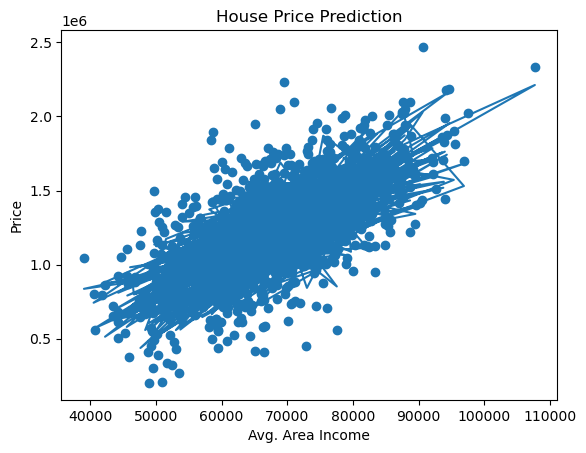

In [166]:
import matplotlib.pyplot as plt
plt.scatter(x_test['Avg. Area Income'],y_test)

plt.plot(
    x_test["Avg. Area Income"],
    y_pred
)
plt.xlabel("Avg. Area Income")
plt.ylabel("Price")
plt.title("House Price Prediction")
plt.show()